# Multiple Lineare Regression – Customer Lifetime Value (CLV)

**Ziel:** Aufbau eines multiplen linearen Regressionsmodells zur Vorhersage des *Customer Lifetime Value* (`CLV_Continuous`).

**Methode:** Lineare Regression mit `LinearRegression` aus `sklearn`  
**Zielvariable:** `CLV_Continuous` (kontinuierlicher numerischer Wert)

**Modellform:**

$$\hat{y}_{CLV} = \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{CBalance} + \hat{\beta}_2 \cdot \text{CEstimatedSalary} + \ldots$$

---

## Vorgehensweise

1. **Daten vorbereiten** – Daten laden und für Regression aufbereiten
2. **Datensatz splitten** – Trainings- und Testdaten erstellen
3. **Modell trainieren** – Multiple lineare Regression fitten
4. **Modell evaluieren** – Güte mit geeigneten Metriken bewerten
5. **Ergebnisse interpretieren** – Koeffizienten und Modellverhalten einordnen

---
### Bibliotheken importieren

In [2]:
# general imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# train_test_split function
from sklearn.model_selection import train_test_split

# linear regression model
from sklearn.linear_model import LinearRegression

# evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

---
### Schritt 1: Daten laden und ersten Überblick verschaffen

Wir laden den Datensatz und verschaffen uns einen ersten Überblick über Struktur, Datentypen und fehlende Werte.

In [3]:
# Datensatz einlesen
df = pd.read_csv('../data/dataset_cleaned.csv')

# Unterteile Datensatz in Feature-Set und Zielvariable (target label)
X = df.drop(['Churn', 'CLV_Continuous'], axis=1)  # Alle Spalten außer Churn und CLV_Continuous
y = df['CLV_Continuous']

print('Features (X) – Shape:', X.shape)
print('Zielvariable (y) – Shape:', y.shape)

Features (X) – Shape: (8521, 23)
Zielvariable (y) – Shape: (8521,)


---
### Schritt 2: Datensatz splitten
Wir teilen den Datensatz in **80 % Trainingsdaten** und **20 % Testdaten** auf.

- `random_state=42` sorgt für **Reproduzierbarkeit** (gleiche Zufallsaufteilung bei jedem Ausführen)
- Trainingsdaten: Das Modell lernt aus diesen Daten
- Testdaten: Unabhängige Bewertung der Modellgüte

In [4]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Trainingsdaten:', X_train.shape)
print('Testdaten:     ', X_test.shape)

Trainingsdaten: (6816, 23)
Testdaten:      (1705, 23)


---
### Schritt 3: Modell trainieren

Wir verwenden eine **multiple lineare Regression** mit `LinearRegression()` aus `sklearn`.

**Warum dieses Verfahren und nicht SGD?**
- Bei rund 8.500 Beobachtungen und 22 Features ist das Verfahren rechnerisch unkritisch
- Kein zwingendes Feature-Scaling erforderlich (anders als bei vielen SGD-Setups)
- Es müssen keine Lernraten oder Epochen feinjustiert werden

In [5]:
# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Vorhersagen auf den Testdaten und Trainingsdaten
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print('Modell erfolgreich trainiert.')

Modell erfolgreich trainiert.


---
### Schritt 4: Evaluationsmetriken sowie Intercept und Koeffizienten

Wir berechnen folgende Metriken:
- **MAE** (Mean Absolute Error): Durchschnittlicher absoluter Fehler in der Originaleinheit (€)
- **MSE** (Mean Squared Error): Mittlerer quadratischer Fehler, der große Fehler stärker bestraft
- **RMSE** (Root Mean Squared Error): Wurzel aus MSE, wieder in Originaleinheit (€) interpretierbar
- **R²** (Bestimmtheitsmaß): Anteil der erklärten Varianz (0 = nichts erklärt, 1 = perfekt)
- **Adjusted R²**: Bereinigtes R², das die Anzahl der Prädiktoren berücksichtigt

In [6]:
# Berechnung der Evaluationsmetriken (Trainingsdaten)
mae_train  = mean_absolute_error(y_train, y_pred_train)
mse_train  = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train   = r2_score(y_train, y_pred_train)

# Adjusted R² berechnen
n_train = X_train.shape[0]   # Anzahl Beobachtungen
k_train = X_train.shape[1]   # Anzahl Features (ohne Konstante)
adj_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - k_train - 1)

print('=== Evaluationsmetriken – Trainingsdaten ===')
print(f'Mean Absolute Error  (MAE):   {mae_train:,.2f}')
print(f'Mean Squared Error   (MSE):   {mse_train:,.2f}')
print(f'Root Mean Sq. Error  (RMSE):  {rmse_train:,.2f}')
print(f'R²-Score:                     {r2_train:.4f}')
print(f'Adjusted R²:                  {adj_r2_train:.4f}')
print()
print('=== Intercept and Coefficients ===')
print(f'Intercept (β₀ / Bias-Term): {model.intercept_:.4f}')
print(f'Coefficients (β₁, β₂, ..., βₖ): {model.coef_}')

=== Evaluationsmetriken – Trainingsdaten ===
Mean Absolute Error  (MAE):   425.43
Mean Squared Error   (MSE):   771,269.03
Root Mean Sq. Error  (RMSE):  878.22
R²-Score:                     0.9740
Adjusted R²:                  0.9739

=== Intercept and Coefficients ===
Intercept (β₀ / Bias-Term): 456.3535
Coefficients (β₁, β₂, ..., βₖ): [ 2.02842584e-02 -1.20843092e+01  2.76709968e+00  7.99595324e-02
  1.24519460e+03  8.10202431e+02  1.25414060e+03  3.99254338e-02
  4.87871617e+01 -9.25602024e-01  5.60066418e-01 -7.43888194e+00
 -1.85300915e+01  1.91092653e+00  3.24299966e+00  5.76949076e+01
  4.97379915e-13 -3.12319025e+01 -5.81192037e+00  4.15862260e+01
  3.50968536e+00  3.31025168e-01  1.27985150e+01]


---
### Evaluation auf Testdaten

Die Evaluation auf den **Testdaten** zeigt, wie gut das Modell auf **unbekannte Daten** generalisiert.
Das ist die entscheidende Kennzahl für die Modellgüte in Machine Learning.

In [7]:
# Vorhersagen auf den Testdaten
predictions_test = model.predict(X_test)

# Berechnung der Evaluationsmetriken (Testdaten)
mae_test  = mean_absolute_error(y_test, predictions_test)
mse_test  = mean_squared_error(y_test, predictions_test)
rmse_test = np.sqrt(mse_test)
r2_test   = r2_score(y_test, predictions_test)

# Adjusted R² berechnen
n_test = X_test.shape[0]
k_test = X_test.shape[1]
adj_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - k_test - 1)

print('=== Evaluationsmetriken – Testdaten ===')
print(f'Mean Absolute Error  (MAE):   {mae_test:,.2f}')
print(f'Mean Squared Error   (MSE):   {mse_test:,.2f}')
print(f'Root Mean Sq. Error  (RMSE):  {rmse_test:,.2f}')
print(f'R²-Score:                     {r2_test:.4f}')
print(f'Adjusted R²:                  {adj_r2_test:.4f}')

=== Evaluationsmetriken – Testdaten ===
Mean Absolute Error  (MAE):   447.19
Mean Squared Error   (MSE):   864,677.00
Root Mean Sq. Error  (RMSE):  929.88
R²-Score:                     0.9710
Adjusted R²:                  0.9706


In [8]:
# Vergleichstabelle Training vs. Test
results = pd.DataFrame({
    'Metrik':  ['MAE', 'MSE', 'RMSE', 'R²', 'Adjusted R²'],
    'Training': [mae_train, mse_train, rmse_train, r2_train, adj_r2_train],
    'Test':     [mae_test,  mse_test,  rmse_test,  r2_test,  adj_r2_test]
})

results = results.set_index('Metrik')
results

,Training,Test
Metrik,,
MAE,425.432439,447.190450
MSE,771269.026073,864676.999876
RMSE,878.219236,929.880100
R²,0.973992,0.970975
Adjusted R²,0.973904,0.970578


---
## Schritt 5: Modell und Koeffizienten des Modells interpretieren

Die geschätzten Koeffizienten (β-Werte) geben an, um wie viel sich der CLV verändert,
wenn ein Feature um eine Einheit steigt – unter der Annahme, dass alle anderen Features konstant bleiben.

In [9]:
# Koeffizienten und Intercept ausgeben
print(f'Intercept (β₀): {model.intercept_:,.4f}')
print()

# Koeffizienten-Tabelle erstellen und nach Betrag sortieren
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Koeffizient': model.coef_
})

coef_df = coef_df.reindex(
    coef_df['Koeffizient'].abs().sort_values(ascending=False).index
)

print('Koeffizienten (sortiert nach absolutem Betrag):')
coef_df

Intercept (β₀): 456.3535

Koeffizienten (sortiert nach absolutem Betrag):


,Feature,Koeffizient
6,CIsActiveMember,1.254141e+03
4,CNumOfProducts,1.245195e+03
5,CHasCrCard,8.102024e+02
15,CBalance_is_negative,5.769491e+01
8,Account_Age_Months,4.878716e+01
19,CGender_Male,4.158623e+01
17,CGeography_Germany,-3.123190e+01
12,Support_Tickets_Count,-1.853009e+01
22,CSeason_Winter,1.279852e+01
1,CAge,-1.208431e+01


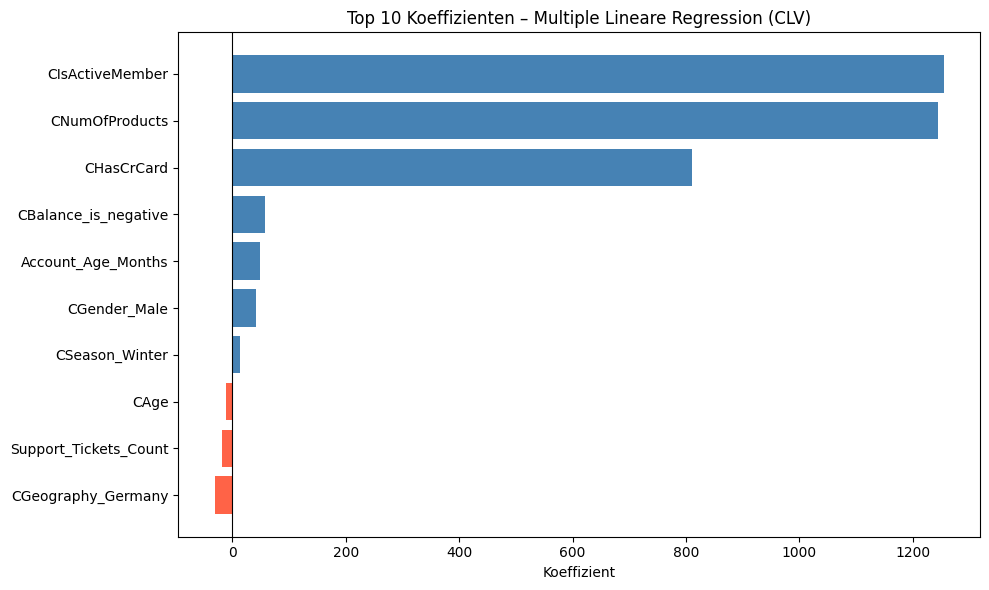

In [10]:
# Visualisierung der Koeffizienten (Top 10 nach absolutem Betrag)
top10 = coef_df.head(10).sort_values('Koeffizient')

colors = ['steelblue' if c > 0 else 'tomato' for c in top10['Koeffizient']]

plt.figure(figsize=(10, 6))
plt.barh(top10['Feature'], top10['Koeffizient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Koeffizient')
plt.title('Top 10 Koeffizienten – Multiple Lineare Regression (CLV)')
plt.tight_layout()
plt.show()

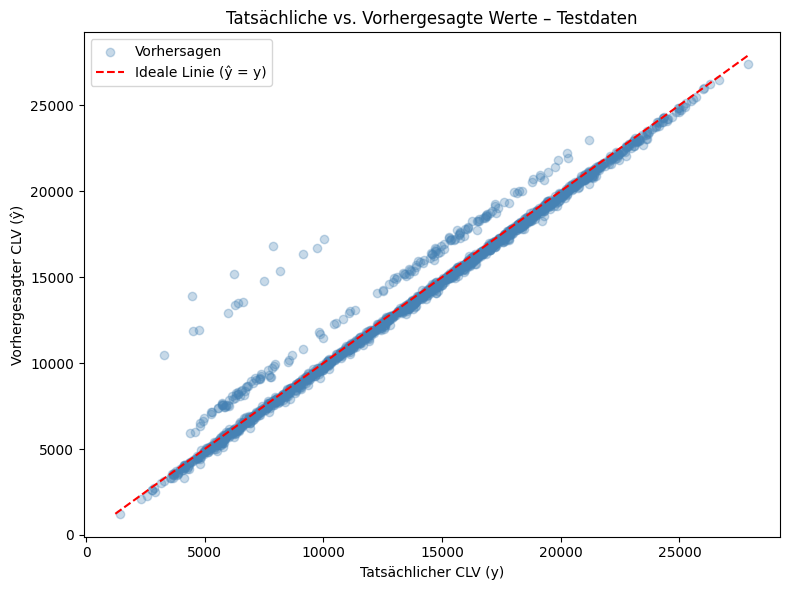

In [11]:
# Visualisierung: Tatsächliche vs. vorhergesagte Werte (Testdaten)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions_test, alpha=0.3, color='steelblue', label='Vorhersagen')

# Ideallinie: perfekte Vorhersage (ŷ = y)
min_val = min(y_test.min(), predictions_test.min())
max_val = max(y_test.max(), predictions_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideale Linie (ŷ = y)')

plt.xlabel('Tatsächlicher CLV (y)')
plt.ylabel('Vorhergesagter CLV (ŷ)')
plt.title('Tatsächliche vs. Vorhergesagte Werte – Testdaten')
plt.legend()
plt.tight_layout()
plt.show()

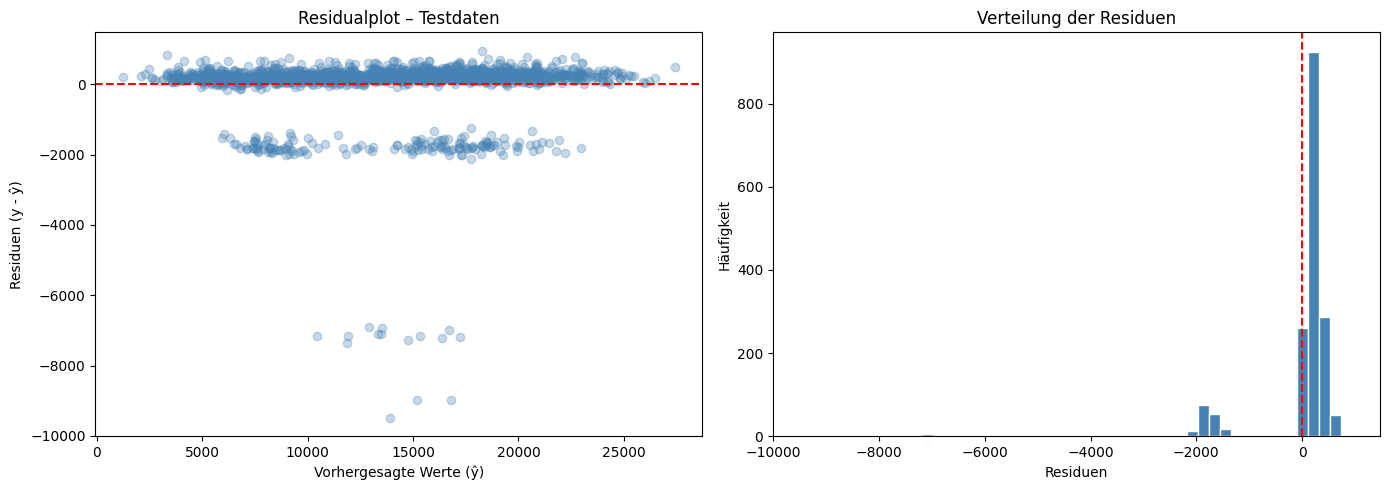

In [12]:
# Residualplot (Testdaten)
residuals = y_test - predictions_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linkes Bild: Residuen vs. Vorhersagen
axes[0].scatter(predictions_test, residuals, alpha=0.3, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Vorhergesagte Werte (ŷ)')
axes[0].set_ylabel('Residuen (y - ŷ)')
axes[0].set_title('Residualplot – Testdaten')

# Rechtes Bild: Verteilung der Residuen (Histogramm)
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residuen')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title('Verteilung der Residuen')

plt.tight_layout()
plt.show()

In [19]:
# Zusammenfassung: Modellformel (Top-3-Features)
top3 = coef_df.head(3)

print('=== Zusammenfassung: Modell & Ergebnisse ===')
print()
print(f'Intercept (β₀):  {model.intercept_:>12,.2f}')
for _, row in top3.iterrows():
    print(f"  {row['Feature']:<30} Koeffizient: {row['Koeffizient']:>10,.4f}")
print('  ... (weitere Features)')
print()
print('--- Evaluationsmetriken (Testdaten) ---')
print(f'MAE:          {mae_test:>10,.2f}  (Ø absoluter Fehler in €)')
print(f'RMSE:         {rmse_test:>10,.2f}  (Fehler in €, große Fehler stärker gewichtet)')
print(f'R²:           {r2_test:>10.4f}  (Anteil der erklärten Varianz)')
print(f'Adjusted R²:  {adj_r2_test:>10.4f}  (R² bereinigt um Anzahl der Features)')
print()
print('--- Mittelwert der Zielgröße ---')
print(f'Mittelwert des CLV: {df["CLV_Continuous"].mean():.2f} €')
print()
print('--- Interpretation des relativen Fehlers ---')
print('Relativer Fehler = RMSE / Mittelwert × 100%')
print(f'Relativer Fehler = {rmse_test:>10,.2f} / {df["CLV_Continuous"].mean():>10,.2f} × 100 = {rmse_test / df["CLV_Continuous"].mean() * 100:.1f} %')


=== Zusammenfassung: Modell & Ergebnisse ===

Intercept (β₀):        456.35
  CIsActiveMember                Koeffizient: 1,254.1406
  CNumOfProducts                 Koeffizient: 1,245.1946
  CHasCrCard                     Koeffizient:   810.2024
  ... (weitere Features)

--- Evaluationsmetriken (Testdaten) ---
MAE:              447.19  (Ø absoluter Fehler in €)
RMSE:             929.88  (Fehler in €, große Fehler stärker gewichtet)
R²:               0.9710  (Anteil der erklärten Varianz)
Adjusted R²:      0.9706  (R² bereinigt um Anzahl der Features)

--- Mittelwert der Zielgröße ---
Mittelwert des CLV: 13674.75 €

--- Interpretation des relativen Fehlers ---
Relativer Fehler = RMSE / Mittelwert × 100%
Relativer Fehler =     929.88 /  13,674.75 × 100 = 6.8 %


### Interpretation der Ergebnisse

#### Evaluationsmetriken
- **MAE / RMSE:** Der durchschnittliche absolute Fehler (MAE) gibt an, um wie viele Euro das Modell den CLV im Schnitt falsch vorhersagt. Der RMSE bestraft größere Fehler stärker.
- **R²:** Mit einem hohen R² auf Trainings- und Testdaten erklärt das Modell einen großen Teil der CLV-Varianz.
- **Adjusted R²:** Da Adjusted R² nahe am R² liegt, gibt es keinen starken Hinweis auf viele nutzlose Prädiktoren im Modell.

#### Wichtigste Einflussgrößen (im aktuellen Modell)
- In den geschätzten Koeffizienten liegen u. a. **`CIsActiveMember`**, **`CNumOfProducts`** und **`CHasCrCard`** vorne.
- Die Aussage „`CBalance` ist das stärkste Feature“ wird durch die aktuelle Koeffizienten-Tabelle **nicht** gestützt.
- Hinweis: Koeffizienten sind über Features mit sehr unterschiedlichen Skalen nur eingeschränkt direkt vergleichbar.

#### Overfitting-Prüfung
- Die Metriken auf Trainings- und Testdaten liegen eng beieinander. Das spricht für gute Generalisierung ohne starkes Overfitting.

#### Residualplot
- Eine weitgehend zufällige Streuung um die Nulllinie spricht dafür, dass das lineare Modell die Hauptstruktur der Daten gut erfasst.

**Zusammenfassung:**
- Das Modell erreicht ein starkes Regressionsniveau. Der relative Fehler liegt bei rund **6,9 %** (RMSE im Verhältnis zum mittleren CLV), was für diese Aufgabe ein gutes Ergebnis ist.